# Review Behavior Analysis
Explore review length, helpfulness, reviewer experience, sentiment, and correlations.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8")

In [2]:
# Load dataset
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)

Loaded: Processed_Reviews.csv
Shape: (16156, 41)


In [3]:
# Validate required columns
required_cols = [
    "Rating",
    "Review_Length",
    "Helpful_Votes",
    "Reviewer_Experience",
    "Length_Bucket"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

In [4]:
# Review length vs rating
length_rating = df.groupby("Length_Bucket")["Rating"].mean()
print("\n=== Avg Rating by Length Bucket ===")
print(length_rating)


=== Avg Rating by Length Bucket ===
Length_Bucket
Long          4.116223
Medium        4.204082
Short         4.229121
Very Short    4.500000
Name: Rating, dtype: float64


In [5]:
# Review length vs helpful votes
length_helpful = df.groupby("Length_Bucket")["Helpful_Votes"].mean()
print("\n=== Avg Helpful Votes by Length Bucket ===")
print(length_helpful)


=== Avg Helpful Votes by Length Bucket ===
Length_Bucket
Long          0.891755
Medium        0.599490
Short         0.446986
Very Short    0.000000
Name: Helpful_Votes, dtype: float64


In [6]:
# Helpful votes vs rating
helpful_rating = df.groupby("Rating")["Helpful_Votes"].mean()
print("\n=== Avg Helpful Votes by Rating ===")
print(helpful_rating)


=== Avg Helpful Votes by Rating ===
Rating
1    2.326489
2    0.992401
3    0.580794
4    0.570824
5    0.712773
Name: Helpful_Votes, dtype: float64


In [7]:
# Reviewer experience analysis
experience_rating = df.groupby("Reviewer_Experience")["Rating"].mean()
experience_helpful = df.groupby("Reviewer_Experience")["Helpful_Votes"].mean()

print("\n=== Avg Rating by Reviewer Experience ===")
print(experience_rating)

print("\n=== Avg Helpful Votes by Reviewer Experience ===")
print(experience_helpful)


=== Avg Rating by Reviewer Experience ===
Reviewer_Experience
Active    4.164789
Casual    4.168902
Expert    4.116818
New       4.232855
Name: Rating, dtype: float64

=== Avg Helpful Votes by Reviewer Experience ===
Reviewer_Experience
Active    0.809051
Casual    0.682993
Expert    0.548387
New       0.759396
Name: Helpful_Votes, dtype: float64


In [8]:
# Review quality score analysis
if "Review_Quality_Score" in df.columns:
    quality_rating = df.groupby("Rating")["Review_Quality_Score"].mean()
    print("\n=== Avg Review Quality Score by Rating ===")
    print(quality_rating)
else:
    quality_rating = None


=== Avg Review Quality Score by Rating ===
Rating
1    0.029135
2    0.023783
3    0.018634
4    0.018201
5    0.018898
Name: Review_Quality_Score, dtype: float64


In [9]:
# Sentiment vs helpful votes
if "Combined_Sentiment" in df.columns:
    sentiment_helpful = df.groupby("Combined_Sentiment")["Helpful_Votes"].mean()
    print("\n=== Avg Helpful Votes by Sentiment ===")
    print(sentiment_helpful)
else:
    sentiment_helpful = None


=== Avg Helpful Votes by Sentiment ===
Combined_Sentiment
NEGATIVE    1.186150
NEUTRAL     0.748075
POSITIVE    0.645174
Name: Helpful_Votes, dtype: float64


In [10]:
# Correlation analysis
numeric_cols = [
    col for col in [
        "Rating",
        "Review_Length",
        "Helpful_Votes",
        "User_Contributions",
        "Review_Quality_Score"
    ]
    if col in df.columns
]
correlation_matrix = df[numeric_cols].corr()

print("\n=== Correlation Matrix ===")
print(correlation_matrix)


=== Correlation Matrix ===
                        Rating  Review_Length  Helpful_Votes  \
Rating                1.000000      -0.056993      -0.040693   
Review_Length        -0.056993       1.000000       0.096055   
Helpful_Votes        -0.040693       0.096055       1.000000   
User_Contributions   -0.020298      -0.005419      -0.008719   
Review_Quality_Score -0.066323       0.919145       0.480387   

                      User_Contributions  Review_Quality_Score  
Rating                         -0.020298             -0.066323  
Review_Length                  -0.005419              0.919145  
Helpful_Votes                  -0.008719              0.480387  
User_Contributions              1.000000             -0.008226  
Review_Quality_Score           -0.008226              1.000000  


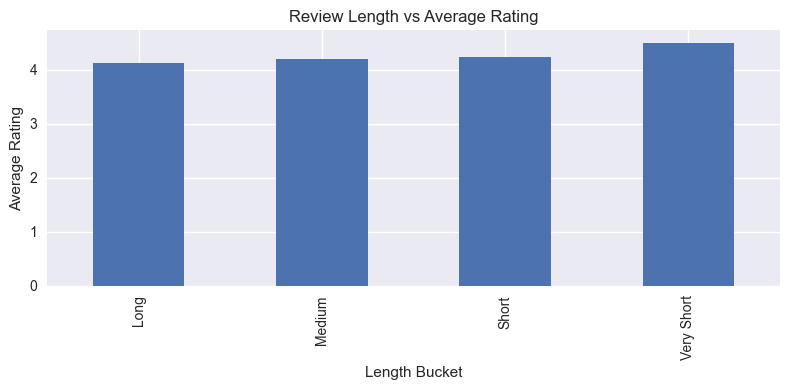

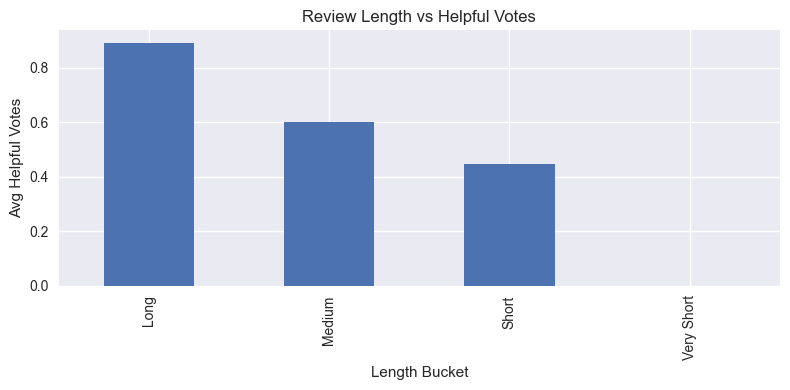

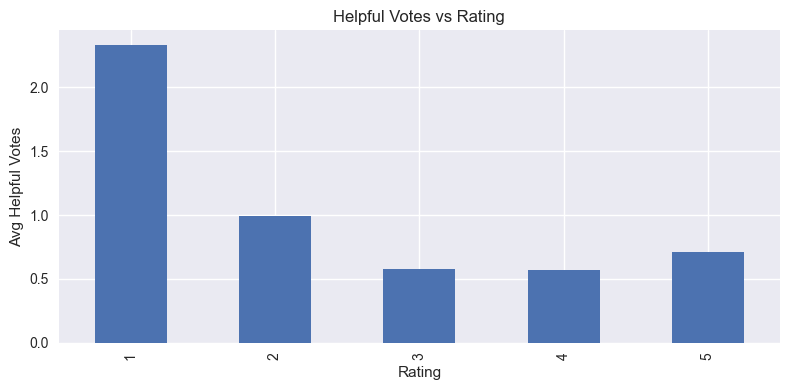

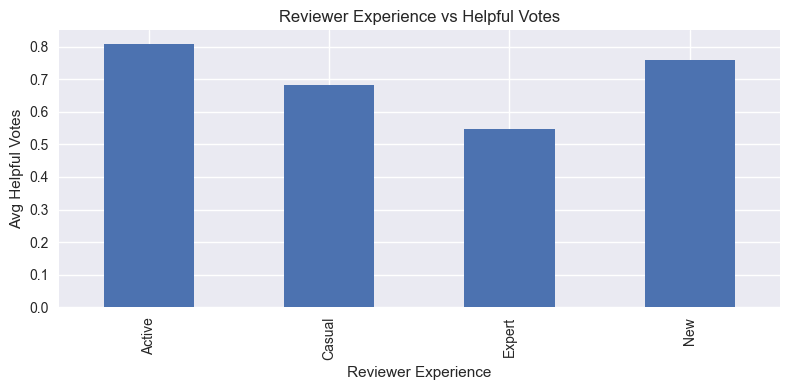

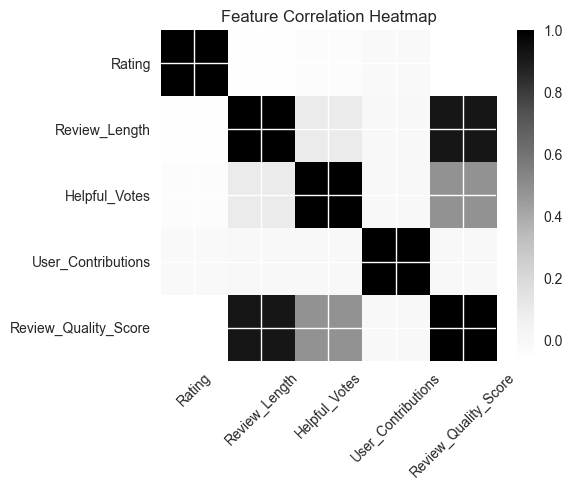

In [11]:
# Plots
plt.figure(figsize=(8, 4))
length_rating.plot(kind="bar")
plt.title("Review Length vs Average Rating")
plt.xlabel("Length Bucket")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
length_helpful.plot(kind="bar")
plt.title("Review Length vs Helpful Votes")
plt.xlabel("Length Bucket")
plt.ylabel("Avg Helpful Votes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
helpful_rating.plot(kind="bar")
plt.title("Helpful Votes vs Rating")
plt.xlabel("Rating")
plt.ylabel("Avg Helpful Votes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
experience_helpful.plot(kind="bar")
plt.title("Reviewer Experience vs Helpful Votes")
plt.xlabel("Reviewer Experience")
plt.ylabel("Avg Helpful Votes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [12]:
# Save outputs
length_rating.to_csv("length_vs_rating.csv")
length_helpful.to_csv("length_vs_helpful.csv")
helpful_rating.to_csv("helpful_vs_rating.csv")
experience_rating.to_csv("experience_vs_rating.csv")
experience_helpful.to_csv("experience_vs_helpful.csv")
correlation_matrix.to_csv("correlation_matrix.csv")

if quality_rating is not None:
    quality_rating.to_csv("quality_vs_rating.csv")

if sentiment_helpful is not None:
    sentiment_helpful.to_csv("sentiment_vs_helpful.csv")

print("\n✅ Review behavior analysis complete.")
print("Saved files:")
print("- length_vs_rating.csv")
print("- length_vs_helpful.csv")
print("- helpful_vs_rating.csv")
print("- experience_vs_rating.csv")
print("- experience_vs_helpful.csv")
print("- correlation_matrix.csv")
if quality_rating is not None:
    print("- quality_vs_rating.csv")
if sentiment_helpful is not None:
    print("- sentiment_vs_helpful.csv")


✅ Review behavior analysis complete.
Saved files:
- length_vs_rating.csv
- length_vs_helpful.csv
- helpful_vs_rating.csv
- experience_vs_rating.csv
- experience_vs_helpful.csv
- correlation_matrix.csv
- quality_vs_rating.csv
- sentiment_vs_helpful.csv
